# VAE - ArtBench

https://www.geeksforgeeks.org/machine-learning/variational-autoencoders/

## Setup

In [1]:
from __future__ import annotations

import sys
import csv
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms 
from torchvision.utils import make_grid
import torchvision.utils as vutils

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
IMAGE_SIZE = 32
BATCH_SIZE = 64 
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Dataset

In [4]:
def find_project_root(start: Path, markers: list[str], max_levels: int = 6) -> Path:
    """Sobe na árvore de pastas até encontrar uma pasta que contenha todos os markers."""
    path = start
    for _ in range(max_levels):
        if all((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise RuntimeError(
        f"PROJECT_ROOT não encontrado a partir de {start}.\n"
        "Estrutura esperada: pasta com 'ArtBench-10/' e 'TP1-alunos-src-only/'."
    )

PROJECT_ROOT      = find_project_root(Path(".").resolve(), ["ArtBench-10", "TP1-alunos-src-only"])
SCRIPTS_DIR       = PROJECT_ROOT / "TP1-alunos-src-only" / "scripts"
KAGGLE_ROOT       = PROJECT_ROOT / "ArtBench-10"
TRAINING_CSV_PATH = PROJECT_ROOT / "TP1-alunos-src-only" / "student_start_pack" / "training_20_percent.csv"

print("PROJECT_ROOT   =", PROJECT_ROOT)
print("SCRIPTS_DIR    =", SCRIPTS_DIR)
print("KAGGLE_ROOT    =", KAGGLE_ROOT)
print("TRAINING CSV   =", TRAINING_CSV_PATH)

assert SCRIPTS_DIR.exists(), f"Não existe: {SCRIPTS_DIR}"
assert KAGGLE_ROOT.exists(), f"Não existe: {KAGGLE_ROOT}"
assert TRAINING_CSV_PATH.exists(), f"Não existe: {TRAINING_CSV_PATH}"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))


PROJECT_ROOT   = C:\Users\Jose\Mestrado\IAG_TP1
SCRIPTS_DIR    = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\scripts
KAGGLE_ROOT    = C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10
TRAINING CSV   = C:\Users\Jose\Mestrado\IAG_TP1\TP1-alunos-src-only\student_start_pack\training_20_percent.csv


In [5]:
%pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [6]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_dataset_completo = hf_ds["train"]

print("Número total de imagens de treino:", len(train_dataset_completo))
print("Colunas:", train_dataset_completo.column_names)

label_feature = train_dataset_completo.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)

print("Número de classes:", num_classes)
print("Classes:", class_names)

c:\Users\Jose\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset source: kaggle root='C:\Users\Jose\Mestrado\IAG_TP1\ArtBench-10'
Número total de imagens de treino: 50000
Colunas: ['image', 'label']
Número de classes: 10
Classes: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [7]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p=0.5), # Inverte a pintura lateralmente
    #transforms.RandomRotation(degrees=10),  # Roda até 10 graus
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform is not None else img
        return x, y, real_idx

def denorm(x):
    '''inverte a normalização Normalize(0.5, 0.5, 0.5) que foi aplicada no transform. As imagens foram guardadas em [-1, 1] (necessário para o Tanh() do gerador), e esta função converte de volta para [0, 1] para poder visualizar com matplotlib.'''
    return (x * 0.5 + 0.5).clamp(0, 1)

In [8]:
INDEX_COLUMN = "train_id_original"

def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    ids = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        if index_column not in (reader.fieldnames or []):
            raise ValueError(f"Coluna {index_column!r} não encontrada. Disponíveis: {reader.fieldnames}")
        for row in reader:
            value = str(row.get(index_column, "")).strip()
            if value:
                ids.append(int(value))
    if len(ids) == 0:
        raise ValueError("Não foram lidos IDs do CSV.")
    return ids

train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, INDEX_COLUMN)

print("Número de IDs lidos do CSV:", len(train_ids_from_csv))
print("Primeiros 10 IDs:", train_ids_from_csv[:10])

Número de IDs lidos do CSV: 10000
Primeiros 10 IDs: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]


In [9]:
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.


In [10]:
train_subset = HFDatasetTorch(train_dataset_completo, transform=transform, indices=train_ids_from_csv)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Tamanho do subset:", len(train_subset))
print("Número de batches:", len(train_loader))


Tamanho do subset: 10000
Número de batches: 157


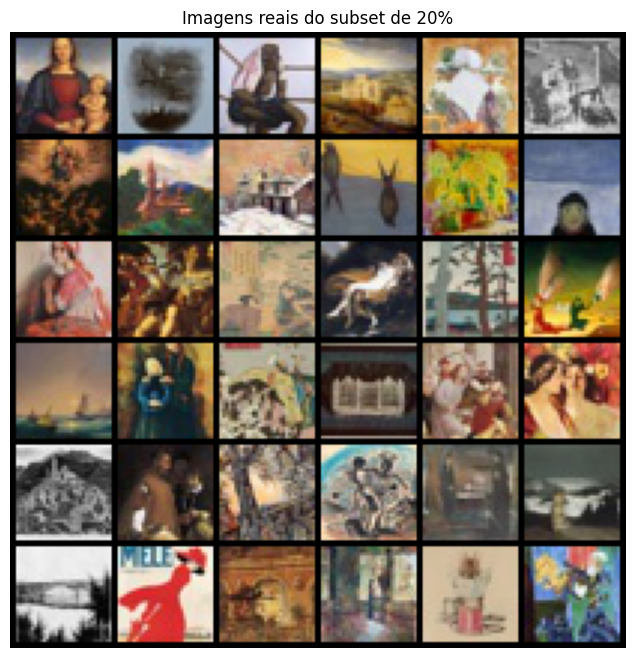

Exemplos de labels:
0: classe=renaissance 
1: classe=romanticism 
2: classe=expressionism 
3: classe=romanticism 
4: classe=post_impressionism 
5: classe=realism 
6: classe=renaissance 
7: classe=post_impressionism 
8: classe=post_impressionism 
9: classe=surrealism 
10: classe=post_impressionism 
11: classe=expressionism 


In [11]:
x, y, idx = next(iter(train_loader))

grid = make_grid(denorm(x[:36]), nrow=6, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("Imagens reais do subset de 20%")
plt.show()

print("Exemplos de labels:")
for i in range(min(12, len(y))):
    print(f"{i}: classe={class_names[int(y[i])]} ")

## Difusion Model

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Parâmetros conforme o artigo
T = 1000  # Timesteps (podes usar 1000 se tiveres GPU forte)
beta_start = 0.0001#0.0001
beta_end = 0.02#0.02

# 1. Linear Schedule para os Betas
betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)

# 2. Derivação dos Alphas (conforme as fórmulas do link)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# 3. Cálculos para o processo Forward (q(x_t | x_0))
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# 4. Cálculos para o processo Backward (posterior variance)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

def get_index_from_list(vals, t, x_shape):
    """Extrai o valor de 'vals' no índice 't' e ajusta o shape para as imagens."""
    batch_size = t.shape[0]
    out = vals.gather(-1, t)
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [13]:
def forward_diffusion_sample(x_0, t, device="cpu"):
    """Recebe imagem limpa x_0 e retorna a versão ruidosa x_t."""
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x_0.shape)
    
    # Média + Variância
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Definição do Embedding de Tempo (Crucial para Difusão)
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, t):
        # t: [Batch]
        shape = t.shape
        sinusoid_inp = torch.outer(t, self.inv_freq)
        emb = torch.cat((sinusoid_inp.sin(), sinusoid_inp.cos()), dim=-1)
        return emb.view(*shape, self.dim)

# 2. Bloco Básico da UNet
class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        # 1. MLP de tempo mais robusto para este bloco
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        
        # 2. Primeira parte: Conv + GroupNorm
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch) # 8 grupos é um padrão comum
        
        # 3. Segunda parte: Conv + GroupNorm
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        
        # 4. Ajuste de dimensões para a conexão residual (se in != out)
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
        self.silu = nn.SiLU()

    def forward(self, x, t):
        # Guardar o input para a conexão residual
        res = self.residual_conv(x)
        
        # Primeira convolução
        h = self.silu(self.norm1(self.conv1(x)))
        
        # Injetar tempo: Transformar [B, out_ch] -> [B, out_ch, 1, 1]
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        
        # Segunda convolução
        h = self.norm2(self.conv2(h))
        
        # Conexão Residual + Ativação final
        return self.silu(h + res)

# 3. A UNet propriamente dita
class SimpleDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        x = self.initial_conv(x)
        
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
            
        for up in self.ups:
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            res = residuals.pop()
            x = torch.cat((x, res), dim=1) 
            x = up(x, t)
            
        return self.final_conv(x)

In [15]:
class SimpleDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        # MLP para processar o passo de tempo t
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )
        
        # Conv inicial para entrar na rede
        self.initial_conv = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)
        
        # Encoder: Baixa a resolução (Downsampling)
        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i+1], time_emb_dim) 
            for i in range(len(down_channels)-1)
        ])
        
        # Decoder: Sobe a resolução (Upsampling)
        # IMPORTANTE: O in_ch do bloco up é o dobro porque recebe o skip connection (concat)
        self.ups = nn.ModuleList([
            Block(up_channels[i] * 2, up_channels[i+1], time_emb_dim) 
            for i in range(len(up_channels)-1)
        ])
        
        # Camada final para voltar a ter 3 canais RGB
        self.final_conv = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t):
        # 1. Embedding do tempo
        t = self.time_mlp(t)
        
        # 2. Passagem inicial
        x = self.initial_conv(x)
        
        # 3. Guardar os residuals para as skip connections
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
            x = F.max_pool2d(x, 2)
            
        # 4. Upsampling com Skip Connections
        for up in self.ups:
            # Sobe a resolução (ex: 16x16 -> 32x32)
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
            
            # Recupera a informação do encoder correspondente
            res = residuals.pop()
            
            # Concatena nos canais (dim=1)
            x = torch.cat((x, res), dim=1) 
            
            # Passa pelo bloco que agora aceita os canais duplicados
            x = up(x, t)
            
        return self.final_conv(x)

In [16]:
model_test = SimpleDiffusionUNet().to(DEVICE)
test_input = torch.randn(1, 3, 32, 32).to(DEVICE)
test_t = torch.randint(0, 300, (1,)).to(DEVICE)
output = model_test(test_input, test_t)

print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}") # Deve ser igual ao input!

Input shape: torch.Size([1, 3, 32, 32])
Output shape: torch.Size([1, 3, 32, 32])


In [17]:
def get_loss(model, x_0, t, device):
    # 1. Gerar ruído e versão ruidosa (Forward)
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    
    # 2. Prever o ruído com a UNet (Backward)
    noise_pred = model(x_noisy, t)
    
    # 3. Calcular o erro (MSE)
    return F.mse_loss(noise, noise_pred)

In [18]:
%pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install torchmetrics[image]
%pip install torch-fidelity

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [26]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance

In [27]:
from pathlib import Path

# 1. Configurações (Ajusta conforme o teu notebook)
# Certifica-te que PROJECT_ROOT, DEVICE, LATENT_DIM e a classe VAE estão definidos
results_dir = Path(r"C:\Users\Jose\Mestrado\IAG_TP1\results")
seeds = [3, 17, 29] #, 58, 71, 89, 123, 256, 456, 512]

In [30]:

def train_and_evaluate_diffusion_seed(seed):
    # 1. Configurar sementes para reprodutibilidade total
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # 2. Inicializar Modelo, Otimizador e Métricas
    model = SimpleDiffusionUNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    fid_metric = FrechetInceptionDistance(feature=2048).to(DEVICE)
    kid_metric = KernelInceptionDistance(subset_size=100).to(DEVICE)
    iteration_losses = []

    best_loss = float('inf')
    patience = 10
    epochs_without_improvement = 0
    # 3. Loop de Treino
    model.train()
    print(f"Iniciando Treino para Seed {seed}...")
    
    for epoch in range(EPOCHS):
        total_epoch_loss = 0
        for batch_idx, (x, _, _) in enumerate(train_loader):
            optimizer.zero_grad()
            x = x.to(DEVICE)
            
            t = torch.randint(0, T, (x.size(0),), device=DEVICE).long()
            loss = get_loss(model, x, t, DEVICE)
            
            loss.backward()
            optimizer.step()
            
            # --- REGISTO POR ITERAÇÃO ---
            current_loss = loss.item()
            iteration_losses.append(current_loss)
            total_epoch_loss += current_loss
        
        avg_loss = total_epoch_loss / len(train_loader)
        
        # Early Stopping
        if avg_loss < best_loss:
            best_loss = avg_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            
        if (epoch + 1) % 5 == 0:
            print(f"Seed {seed} | Época {epoch+1} | Loss: {avg_loss:.6f}")

        if epochs_without_improvement >= patience:
            print(f"Early Stopping na época {epoch+1}!")
            break

    # --- NOVO: CÓDIGO DO PLOT DA LOSS ---
    plt.figure(figsize=(10, 5))
    plt.plot(iteration_losses, alpha=0.3, label='Loss por Iteração', color='tab:blue')

    
    plt.title(f"Convergência da Loss - Seed {seed}")
    plt.xlabel("Iteração (Batch)")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show() # Ou plt.savefig(f"loss_seed_{seed}.png")
    # 4. Avaliação Final (Processo de Amostragem DDPM)
    model.eval()
    print(f"A gerar amostras para avaliação da Seed {seed}...")
    
    # Precisamos de imagens reais para o FID/KID
    # E gerar imagens fakes do zero usando o processo reverso
    with torch.no_grad():
        # A. Atualizar métricas com imagens REAIS
        for x, _, _ in train_loader:
            real = ((x * 0.5 + 0.5) * 255).clamp(0, 255).to(torch.uint8).to(DEVICE)
            fid_metric.update(real, real=True)
            kid_metric.update(real, real=True)
            if fid_metric.real_features_num_samples >= 1000:
                break

        # B. Gerar imagens FAKES (Processo de Sampling Completo)
        # Geramos em batches para não estourar a memória
        num_generated = 0
        batch_size_gen = 64 # Podes ajustar conforme a tua GPU
        
        while num_generated < 1000:
            # Começar com ruído puro
            img = torch.randn((batch_size_gen, 3, 32, 32), device=DEVICE)
            
            # Loop reverso de T até 0
            for i in reversed(range(0, T)):
                t_idx = torch.full((batch_size_gen,), i, device=DEVICE, dtype=torch.long)
                predicted_noise = model(img, t_idx)
                
                # Coeficientes do Scheduler (alphas, betas, etc. definidos globalmente)
                alpha = get_index_from_list(alphas, t_idx, img.shape)
                alpha_cumprod_t = get_index_from_list(alphas_cumprod, t_idx, img.shape)
                beta_t = get_index_from_list(betas, t_idx, img.shape)
                
                if i > 0:
                    noise = torch.randn_like(img)
                else:
                    noise = 0
                
                # Fórmula de x_{t-1}
                img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise) + torch.sqrt(beta_t) * noise
            
            # Converter para uint8 [0, 255]
            fake = ((img.clamp(-1, 1) * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(fake, real=False)
            kid_metric.update(fake, real=False)
            
            num_generated += batch_size_gen

    # 5. Compilar resultados
    fid_score = fid_metric.compute().item()
    kid_mean, kid_std = kid_metric.compute()
    
    model_save_path = results_dir / f"diffusion_model_100_epochs_T1000_seed{seed}.pth"
    torch.save(model.state_dict(), model_save_path)

    return {
        "seed": seed,
        "metrics": {
            "fid": fid_score,
            "kid": kid_mean.item(),
            "kid_std": kid_std.item()
        }
    }

In [31]:
%pip install torchmetrics[image]

Note: you may need to restart the kernel to use updated packages.


Iniciando Protocolo de Difusão para 3 seeds...

--- A processar Seed Difusão: 3 ---
Iniciando Treino para Seed 3...
Seed 3 | Época 5 | Loss: 0.050385
Seed 3 | Época 10 | Loss: 0.043834
Seed 3 | Época 15 | Loss: 0.040837
Seed 3 | Época 20 | Loss: 0.039375
Seed 3 | Época 25 | Loss: 0.037280
Seed 3 | Época 30 | Loss: 0.038330
Seed 3 | Época 35 | Loss: 0.039805
Early Stopping na época 35!


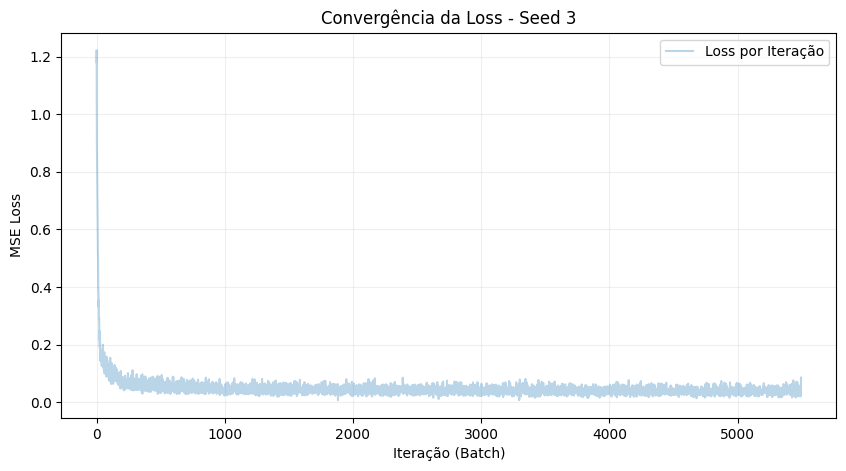

A gerar amostras para avaliação da Seed 3...
Seed 3 concluída em 17.57 min | FID: 164.04

--- A processar Seed Difusão: 17 ---
Iniciando Treino para Seed 17...
Seed 17 | Época 5 | Loss: 0.050706
Seed 17 | Época 10 | Loss: 0.042799
Seed 17 | Época 15 | Loss: 0.041438
Seed 17 | Época 20 | Loss: 0.041277
Seed 17 | Época 25 | Loss: 0.038846
Seed 17 | Época 30 | Loss: 0.039185
Seed 17 | Época 35 | Loss: 0.037129
Seed 17 | Época 40 | Loss: 0.038022
Seed 17 | Época 45 | Loss: 0.038301
Early Stopping na época 45!


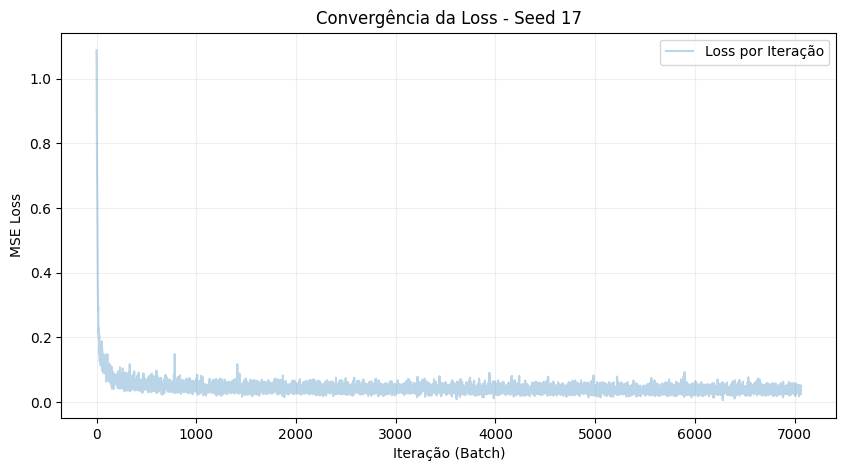

A gerar amostras para avaliação da Seed 17...
Seed 17 concluída em 19.86 min | FID: 144.86

--- A processar Seed Difusão: 29 ---
Iniciando Treino para Seed 29...
Seed 29 | Época 5 | Loss: 0.050784
Seed 29 | Época 10 | Loss: 0.044749
Seed 29 | Época 15 | Loss: 0.041156
Seed 29 | Época 20 | Loss: 0.040009
Seed 29 | Época 25 | Loss: 0.038493
Seed 29 | Época 30 | Loss: 0.038800
Early Stopping na época 31!


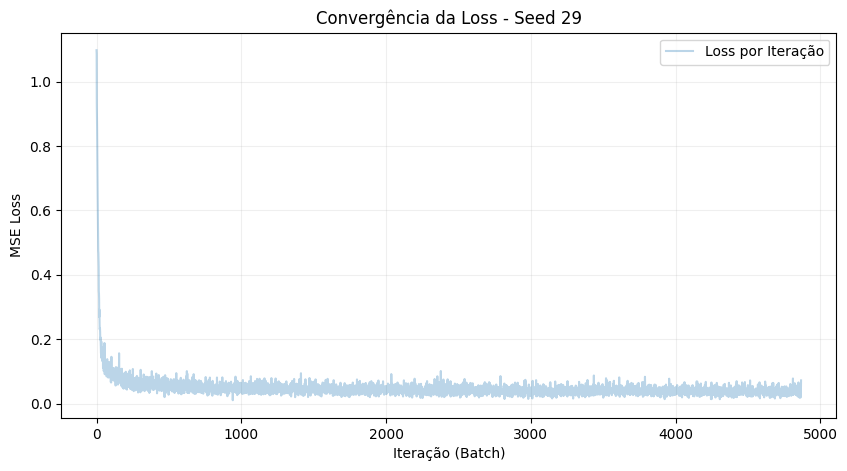

A gerar amostras para avaliação da Seed 29...
Seed 29 concluída em 16.75 min | FID: 152.99

RESUMO FINAL DIFUSÃO
FID: 153.96 ± 7.86
KID: 0.1086 ± 0.0150
Resultados guardados em: C:\Users\Jose\Mestrado\IAG_TP1\results


In [32]:
import json
import time
from pathlib import Path
import numpy as np

# 1. Configurações de Caminhos e Seeds
# Usa a tua string direta como preferiste antes
results_dir = Path(r"C:\Users\Jose\Mestrado\IAG_TP1\results")
results_dir.mkdir(parents=True, exist_ok=True)

seeds_diffusion = [3, 17, 29] #, 58, 71, 89, 123, 256, 456, 512]


all_diffusion_results = []

print(f"Iniciando Protocolo de Difusão para {len(seeds_diffusion)} seeds...")
start_global = time.time()

for s in seeds_diffusion:
    print(f"\n--- A processar Seed Difusão: {s} ---")
    start_seed = time.time()
    
    # Chama a função que criámos no passo anterior
    # Certifica-te que a função 'train_and_evaluate_diffusion_seed' está definida
    try:
        res = train_and_evaluate_diffusion_seed(s)
        all_diffusion_results.append(res)
        
        # Guardar JSON individual imediatamente (prevenção de crashes)
        seed_path = results_dir / f"metrics_diffusion_100_epochs_T1000_seed{s}.json"
        with open(seed_path, "w", encoding="utf-8") as f:
            json.dump(res, f, indent=2)
            
        duracao = (time.time() - start_seed) / 60
        print(f"Seed {s} concluída em {duracao:.2f} min | FID: {res['metrics']['fid']:.2f}")
        
    except Exception as e:
        print(f"Erro na Seed {s}: {e}")

# 2. Cálculo das Estatísticas Finais (Mean ± Std)
if all_diffusion_results:
    fids = [r["metrics"]["fid"] for r in all_diffusion_results]
    kids = [r["metrics"]["kid"] for r in all_diffusion_results]
    
    summary_diff = {
        "statistics": {
            "fid_mean": float(np.mean(fids)),
            "fid_std": float(np.std(fids)),
            "kid_mean": float(np.mean(kids)),
            "kid_std": float(np.std(kids))
        },
        "all_seeds": all_diffusion_results,
        "total_duration_minutes": (time.time() - start_global) / 60
    }

    # 3. Guardar o Resumo Final
    summary_path = results_dir / "diffusion_statistical_summary_100_epochs_T1000.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary_diff, f, indent=2)

    print("\n" + "="*50)
    print("RESUMO FINAL DIFUSÃO")
    print("="*50)
    print(f"FID: {summary_diff['statistics']['fid_mean']:.2f} ± {summary_diff['statistics']['fid_std']:.2f}")
    print(f"KID: {summary_diff['statistics']['kid_mean']:.4f} ± {summary_diff['statistics']['kid_std']:.4f}")
    print(f"Resultados guardados em: {results_dir}")
    print("="*50)

A carregar modelos de: C:\Users\Jose\Mestrado\IAG_TP1\results

Gerando amostras para a Seed 3...


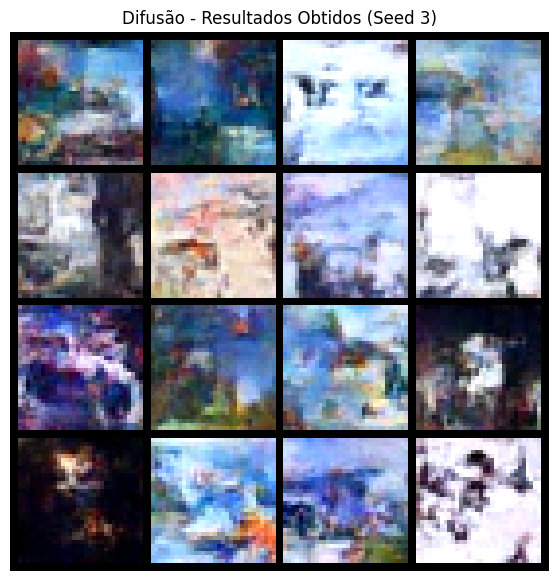


Gerando amostras para a Seed 17...


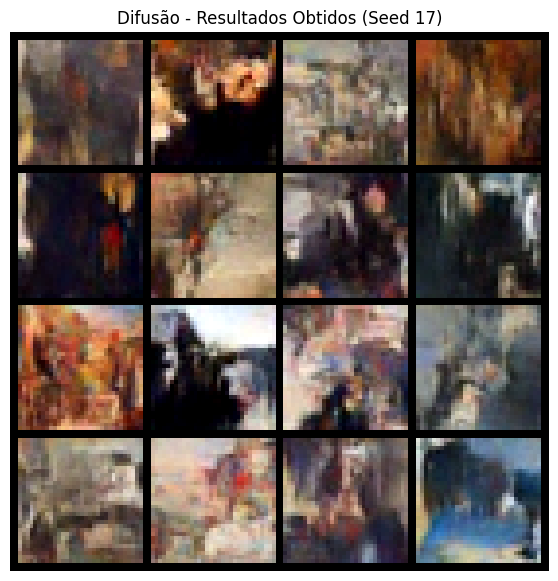


Gerando amostras para a Seed 29...


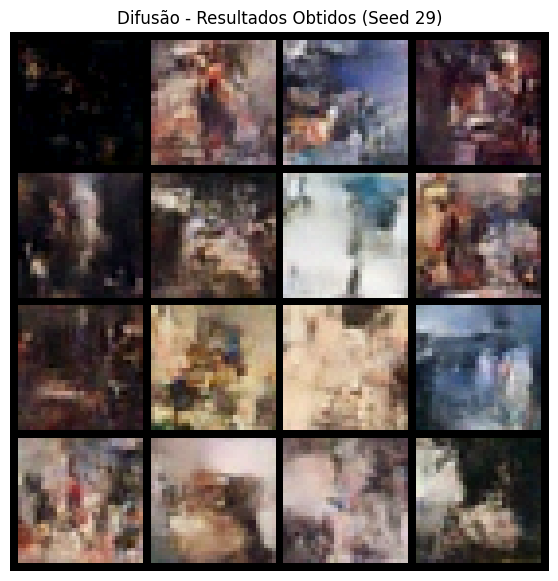

In [33]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from pathlib import Path

@torch.no_grad()
def load_and_visualize_diffusion(seeds_list, results_path, n_samples=16):
    # 1. Instanciar a arquitetura (tem de ser a mesma usada no treino)
    model = SimpleDiffusionUNet().to(DEVICE)
    results_path = Path(results_path)
    
    print(f"A carregar modelos de: {results_path}")

    for seed in seeds_list:
        # Procurar o ficheiro .pth da seed específica
        model_file = results_path / f"diffusion_model_100_epochs_T1000_seed{seed}.pth"
        
        if not model_file.exists():
            print(f"Ficheiro não encontrado: {model_file.name}")
            continue
            
        print(f"\nGerando amostras para a Seed {seed}...")
        
        # CARREGAR OS PESOS
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        model.eval()
        
        # PROCESSO DE DENOISING (Processo Reverso)
        # Começamos com ruído aleatório
        img = torch.randn((n_samples, 3, 32, 32), device=DEVICE)
        
        for i in reversed(range(0, T)):
            t = torch.full((n_samples,), i, device=DEVICE, dtype=torch.long)
            
            # Prever o ruído com o modelo carregado
            predicted_noise = model(img, t)
            
            # Recuperar parâmetros do scheduler (devem estar no teu ambiente global)
            alpha = get_index_from_list(alphas, t, img.shape)
            alpha_cumprod_t = get_index_from_list(alphas_cumprod, t, img.shape)
            beta_t = get_index_from_list(betas, t, img.shape)
            
            if i > 0:
                noise = torch.randn_like(img)
            else:
                noise = 0
                
            # Fórmula de x_{t-1}
            img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise) \
                  + torch.sqrt(beta_t) * noise
        
        # Formatação final para visualização
        img = (img.clamp(-1, 1) + 1) / 2
        grid = make_grid(img, nrow=4, padding=2).permute(1, 2, 0).cpu().numpy()
        
        plt.figure(figsize=(7, 7))
        plt.imshow(grid)
        plt.axis('off')
        plt.title(f"Difusão - Resultados Obtidos (Seed {seed})")
        plt.show()

# --- EXECUÇÃO ---
# Usa o caminho da tua pasta onde estão os .pth
resultados = r"C:\Users\Jose\Mestrado\IAG_TP1\results"
seeds = [3, 17, 29] #, 58, 71, 89, 123, 256, 456, 512]


load_and_visualize_diffusion(seeds, resultados, n_samples=16)

In [ ]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

def reconstrucao_difusao(model, loader, scheduler, device, timesteps_noise=300, n=8):
    """
    model: A tua UNet ou modelo de difusão treinado
    loader: DataLoader com imagens reais (ex: test_loader)
    scheduler: O objeto que controla o ruído (ex: DDPMScheduler)
    timesteps_noise: Quanto ruído adicionar (0 a 1000). 
                     Mais ruído = reconstrução mais criativa/difícil.
    """
    model.eval()
    
    # 1. Obter imagens reais
    batch = next(iter(loader))
    x_real, _, _ = batch
    x_real = x_real[:n].to(device)
    
    # 2. Adicionar ruído (Forward Process)
    # Escolhemos um ponto 't' (ex: 300 de 1000) para "estragar" a imagem
    t_idx = torch.full((n,), timesteps_noise, device=device, dtype=torch.long)
    noise = torch.randn_like(x_real)
    x_noisy = scheduler.add_noise(x_real, noise, t_idx)
    
    # 3. Reconstruir (Reverse Process / Denoising)
    x_recon = x_noisy
    print(f"A reconstruir imagens a partir do timestep {timesteps_noise}...")
    
    for i in tqdm(reversed(range(0, timesteps_noise))):
        t_curr = torch.full((n,), i, device=device, dtype=torch.long)
        with torch.no_grad():
            # O modelo prevê o ruído presente na imagem atual
            # Nota: dependendo da tua implementação, pode ser model(x_recon, t_curr).sample
            residual = model(x_recon, t_curr) 
            
            # O scheduler remove esse ruído para dar o passo anterior
            x_recon = scheduler.step(residual, i, x_recon).prev_sample

    # 4. Visualização
    def denorm(t):
        return (t.clamp(-1, 1) + 1) / 2

    x_real_plot = denorm(x_real).cpu().permute(0, 2, 3, 1).numpy()
    x_noisy_plot = denorm(x_noisy).cpu().permute(0, 2, 3, 1).numpy()
    x_recon_plot = denorm(x_recon).cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 6))
    for i in range(n):
        axes[0, i].imshow(x_real_plot[i])
        axes[0, i].set_title("Original")
        axes[1, i].imshow(x_noisy_plot[i])
        axes[1, i].set_title("Com Ruído")
        axes[2, i].imshow(x_recon_plot[i])
        axes[2, i].set_title("Reconstruída")
        for row in range(3): axes[row, i].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path

# Configurações
results_dir = Path(r"D:\Mestrado\2ºsemestre\IAG\IAG_TP1\results_diffusion")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Instanciar a arquitetura do modelo (UNet) e o Scheduler
# Substitui 'UNet' e 'DDPMScheduler' pelas classes que usaste no treino
meu_modelo = MinhaUNet().to(device) 
meu_scheduler = MeuScheduler() 

# 2. Carregar os pesos de uma seed específica
seed_a_testar = 89
model_path = results_dir / f"diffusion_model_seed{seed_a_testar}.pth"

if model_path.exists():
    checkpoint = torch.load(model_path, map_location=device)
    meu_modelo.load_state_dict(checkpoint)
    print(f"Modelo da seed {seed_a_testar} carregado com sucesso!")
    
    # 3. Executar a reconstrução
    # timesteps_noise=100 reconstrói quase igual. 500 reconstrói "estilo". 1000 é geração pura.
    reconstrucao_difusao(meu_modelo, train_loader, meu_scheduler, device, timesteps_noise=250)
else:
    print("Ficheiro não encontrado.")